In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import yfinance as yf
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import os
import pickle

# ── CONFIG ──────────────────────────────────────────────────────────────────
TICKER      = '^NSEI'
START_DATE  = '2000-01-01'
END_DATE    = '2024-12-31'
DATA_PATH   = 'data/01_labeled_regimes.csv'
RANDOM_SEED = 42

os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)

REGIME_COLOR = {'Bear': '#e74c3c', 'Sideways': '#f39c12', 'Bull': '#2ecc71'}

print('Imports OK')

Imports OK


In [2]:
# Load the labeled dataset saved by Notebook 01
base_df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
print(f'Loaded labeled dataset: {base_df.shape}')
print(f'Columns: {list(base_df.columns)}')
base_df.tail(3)

Loaded labeled dataset: (4120, 16)
Columns: ['log_return', 'realized_vol', 'daily_range', 'Close', 'regime_raw', 'regime_name', 'regime_code', 'vix', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_5d_mean', 'ret_21d_mean', 'target_regime_code', 'target_regime_name']


,log_return,realized_vol,daily_range,Close,regime_raw,regime_name,regime_code,vix,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ret_5d_mean,ret_21d_mean,target_regime_code,target_regime_name
Date,,,,,,,,,,,,,,,,
2024-12-24,-0.001087,0.123498,0.007691,23727.650391,0,Bull,2,13.18,0.007011,-0.015322,-0.010266,-0.013560,-0.007558,-0.000307,2.0,Bull
2024-12-26,0.000950,0.123677,0.008459,23750.199219,0,Bull,2,14.04,-0.001087,0.007011,-0.015322,-0.005652,-0.005063,-0.000982,2.0,Bull
2024-12-27,0.002658,0.123415,0.005806,23813.400391,0,Bull,2,13.24,0.000950,-0.001087,0.007011,-0.010266,-0.003743,-0.000883,2.0,Bull


In [4]:
# We need the full OHLCV data for technical indicators
# Reload raw price data
print('Downloading raw OHLCV for feature computation...')
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw.index = pd.to_datetime(raw.index)

# Also reload VIX
vix_raw = yf.download('^INDIAVIX', start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_raw.index = pd.to_datetime(vix_raw.index)

print(f'Raw OHLCV: {raw.shape} | VIX: {vix_raw.shape}')

Raw OHLCV: (4237, 5) | VIX: (4121, 5)


---
## 2. Feature Engineering

### ⚠️ The Golden Rule: No Lookahead Bias
Every feature must only use information available at time `t` to predict the regime at time `t+1`.

- **Rolling windows**: use `.shift(1)` after computing to ensure we're using *completed* windows
- **Indicators like RSI/MACD**: computed on all data but `.shift(1)` applied so today's model only sees yesterday's indicator
- **Target**: already shifted forward by 1 in Notebook 01

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 1: MOMENTUM FEATURES
# Capture return magnitude and direction over multiple horizons
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Multi-period momentum features.
    All features are shifted by 1 to prevent lookahead.
    """
    out = pd.DataFrame(index=df.index)
    close = df['Close']
    log_ret = np.log(close / close.shift(1))

    # Point-in-time returns over different lookbacks
    for period in [1, 2, 3, 5, 10, 21, 63]:
        out[f'ret_{period}d'] = np.log(close / close.shift(period)).shift(1)

    # Rolling mean returns — smoothed momentum
    for window in [5, 10, 21, 63]:
        out[f'ret_mean_{window}d'] = log_ret.rolling(window).mean().shift(1)

    # Rate of Change (percentage)
    for period in [5, 21]:
        out[f'roc_{period}d'] = ((close - close.shift(period)) / close.shift(period)).shift(1)

    # Momentum consistency: fraction of up days in last N days
    for window in [5, 21]:
        out[f'up_frac_{window}d'] = (log_ret > 0).rolling(window).mean().shift(1)

    return out


mom_df = momentum_features(raw)
print(f'Momentum features: {mom_df.shape[1]} columns')
mom_df.tail(2)

Momentum features: 15 columns


,ret_1d,ret_2d,ret_3d,ret_5d,ret_10d,ret_21d,ret_63d,ret_mean_5d,ret_mean_10d,ret_mean_21d,ret_mean_63d,roc_5d,roc_21d,up_frac_5d,up_frac_21d
Date,,,,,,,,,,,,,,,
2024-12-27,0.000950,-0.000137,0.006874,-0.018714,-0.036853,-0.018534,-0.088211,-0.003743,-0.003685,-0.000883,-0.001400,-0.018540,-0.018364,0.4,0.47619
2024-12-30,0.002658,0.003607,0.002521,-0.005791,-0.030410,-0.019194,-0.088008,-0.001158,-0.003041,-0.000914,-0.001397,-0.005774,-0.019011,0.6,0.47619


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 2: TREND FEATURES
# Identify whether market is in a trending or ranging state
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    SMA ratios, MACD, and ADX (trend strength).
    """
    out = pd.DataFrame(index=df.index)
    close = df['Close']

    # SMA ratios: price relative to moving averages
    # > 1 means price is above SMA (uptrend proxy)
    for window in [20, 50, 100, 200]:
        sma = close.rolling(window).mean()
        out[f'price_sma{window}_ratio'] = (close / sma).shift(1)

    # SMA crossovers (e.g., golden cross / death cross)
    sma50  = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    out['sma50_200_ratio'] = (sma50 / sma200).shift(1)
    out['golden_cross']    = (sma50 > sma200).astype(int).shift(1)  # 1=golden, 0=death

    # MACD — pandas_ta computes MACD signal and histogram
    macd = ta.macd(close, fast=12, slow=26, signal=9)
    out['macd_line']   = macd['MACD_12_26_9'].shift(1)
    out['macd_signal'] = macd['MACDs_12_26_9'].shift(1)
    out['macd_hist']   = macd['MACDh_12_26_9'].shift(1)
    out['macd_crossover'] = (macd['MACD_12_26_9'] > macd['MACDs_12_26_9']).astype(int).shift(1)

    # ADX — measures trend *strength*, not direction (0=choppy, 100=strong trend)
    adx = ta.adx(df['High'], df['Low'], close, length=14)
    out['adx']      = adx['ADX_14'].shift(1)
    out['adx_pos']  = adx['DMP_14'].shift(1)   # +DI
    out['adx_neg']  = adx['DMN_14'].shift(1)   # -DI
    out['adx_trend_strength'] = (adx['ADX_14'] > 25).astype(int).shift(1)  # 1=trending

    return out


trend_df = trend_features(raw)
print(f'Trend features: {trend_df.shape[1]} columns')
trend_df.tail(2)

Trend features: 14 columns


,price_sma20_ratio,price_sma50_ratio,price_sma100_ratio,price_sma200_ratio,sma50_200_ratio,golden_cross,macd_line,macd_signal,macd_hist,macd_crossover,adx,adx_pos,adx_neg,adx_trend_strength
Date,,,,,,,,,,,,,,
2024-12-27,0.977790,0.979447,0.963455,0.995646,1.016539,1.0,-131.975939,-38.179329,-93.796610,0.0,29.065866,11.679590,34.617924,1.0
2024-12-30,0.980595,0.983062,0.966373,0.998001,1.015196,1.0,-141.269558,-58.797375,-82.472184,0.0,30.030317,13.272793,32.948256,1.0


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 3: VOLATILITY FEATURES
# Volatility is the single best discriminator between regimes
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realized volatility, ATR, Bollinger Band metrics, volatility ratios.
    """
    out = pd.DataFrame(index=df.index)
    close = df['Close']
    log_ret = np.log(close / close.shift(1))

    # Realized volatility at multiple horizons (annualized)
    for window in [5, 10, 21, 63]:
        rv = log_ret.rolling(window).std() * np.sqrt(252)
        out[f'realized_vol_{window}d'] = rv.shift(1)

    # Volatility ratio: short vol / long vol — rising = vol expansion
    rv5  = log_ret.rolling(5).std()
    rv21 = log_ret.rolling(21).std()
    out['vol_ratio_5_21'] = (rv5 / rv21).shift(1)

    # Parkinson volatility: uses High-Low range (more efficient than close-to-close)
    hl_log = np.log(df['High'] / df['Low'])
    out['parkinson_vol'] = (hl_log ** 2 / (4 * np.log(2))).rolling(21).mean().apply(np.sqrt).shift(1) * np.sqrt(252)

    # ATR — Average True Range (absolute volatility measure)
    atr = ta.atr(df['High'], df['Low'], close, length=14)
    out['atr']           = atr.shift(1)
    out['atr_pct']       = (atr / close).shift(1)  # Normalized ATR

    # Bollinger Bands
    bb = ta.bbands(close, length=20, std=2)
    print(f'BB columns: {bb.columns}')
    out['bb_width']      = ((bb['BBU_20_2.0_2.0'] - bb['BBL_20_2.0_2.0']) / bb['BBM_20_2.0_2.0']).shift(1)
    out['bb_pct_b']      = bb['BBP_20_2.0_2.0'].shift(1)  # %B: 0=lower band, 1=upper band
    out['bb_squeeze']    = (out['bb_width'] < out['bb_width'].rolling(125).quantile(0.2)).astype(int)  # squeeze signal

    return out


vol_df = volatility_features(raw)
print(f'Volatility features: {vol_df.shape[1]} columns')
vol_df.tail(2)

BB columns: Index(['BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'BBB_20_2.0_2.0',
       'BBP_20_2.0_2.0'],
      dtype='object')
Volatility features: 11 columns


,realized_vol_5d,realized_vol_10d,realized_vol_21d,realized_vol_63d,vol_ratio_5_21,parkinson_vol,atr,atr_pct,bb_width,bb_pct_b,bb_squeeze
Date,,,,,,,,,,,
2024-12-27,0.142286,0.127593,0.123677,0.131500,1.150463,0.118305,286.362914,0.012057,0.063653,0.151074,0
2024-12-30,0.134317,0.131491,0.123415,0.131525,1.088332,0.117559,279.383448,0.011732,0.064616,0.199689,0


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 4: MEAN REVERSION FEATURES
# Overbought / oversold conditions + distance from statistical mean
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def mean_reversion_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    RSI, Z-score of price, drawdown from highs.
    """
    out = pd.DataFrame(index=df.index)
    close = df['Close']
    log_ret = np.log(close / close.shift(1))

    # RSI at multiple periods
    for period in [7, 14, 28]:
        out[f'rsi_{period}'] = ta.rsi(close, length=period).shift(1)

    # Z-score: how many std deviations is price from its rolling mean?
    for window in [21, 63]:
        roll_mean = close.rolling(window).mean()
        roll_std  = close.rolling(window).std()
        out[f'zscore_{window}d'] = ((close - roll_mean) / roll_std).shift(1)

    # Drawdown from rolling 252-day high (bear market proxy)
    rolling_high = close.rolling(252, min_periods=1).max()
    out['drawdown_252d'] = ((close - rolling_high) / rolling_high).shift(1)

    # Drawdown from rolling 63-day high (shorter-term)
    rolling_high_63 = close.rolling(63, min_periods=1).max()
    out['drawdown_63d'] = ((close - rolling_high_63) / rolling_high_63).shift(1)

    # Return z-score: is today's return extreme?
    out['ret_zscore_21d'] = ((log_ret - log_ret.rolling(21).mean()) / log_ret.rolling(21).std()).shift(1)

    # Stochastic oscillator %K
    stoch = ta.stoch(df['High'], df['Low'], close, k=14, d=3)
    out['stoch_k'] = stoch['STOCHk_14_3_3'].shift(1)
    out['stoch_d'] = stoch['STOCHd_14_3_3'].shift(1)

    return out


mr_df = mean_reversion_features(raw)
print(f'Mean reversion features: {mr_df.shape[1]} columns')
mr_df.tail(2)

Mean reversion features: 10 columns


,rsi_7,rsi_14,rsi_28,zscore_21d,zscore_63d,drawdown_252d,drawdown_63d,ret_zscore_21d,stoch_k,stoch_d
Date,,,,,,,,,,
2024-12-27,31.575978,38.838312,42.987092,-1.430041,-1.150195,-0.094059,-0.094059,0.235205,15.913120,12.302633
2024-12-30,36.224432,40.736696,43.848167,-1.160647,-1.037239,-0.091648,-0.091648,0.459399,17.790025,15.076237


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 5: VOLUME FEATURES
# Volume confirms price moves — high volume trend = conviction
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def volume_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    OBV, volume ratios, volume z-score.
    """
    out = pd.DataFrame(index=df.index)
    close = df['Close']
    volume = df['Volume']

    # Volume ratio: today vs 21-day average (surge = >1)
    vol_ma21 = volume.rolling(21).mean()
    out['volume_ratio_21d'] = (volume / vol_ma21).shift(1)

    # Volume z-score
    out['volume_zscore_21d'] = ((volume - vol_ma21) / volume.rolling(21).std()).shift(1)

    # On-Balance Volume (OBV) trend: rising OBV = accumulation, falling = distribution
    obv = ta.obv(close, volume)
    obv_sma20 = obv.rolling(20).mean()
    out['obv_trend'] = (obv > obv_sma20).astype(int).shift(1)  # 1=accumulation

    # Up/Down volume ratio (requires VWAP estimate)
    log_ret = np.log(close / close.shift(1))
    up_vol   = volume.where(log_ret > 0, 0).rolling(21).sum()
    down_vol = volume.where(log_ret < 0, 0).rolling(21).sum()
    out['up_down_vol_ratio'] = (up_vol / (down_vol + 1e-9)).shift(1)

    # Price-volume divergence: price up but volume down = weak move
    price_direction = np.sign(log_ret)
    volume_direction = np.sign(volume - vol_ma21)
    out['pv_divergence'] = (price_direction != volume_direction).astype(int).shift(1)

    return out


vol_feat_df = volume_features(raw)
print(f'Volume features: {vol_feat_df.shape[1]} columns')
vol_feat_df.tail(2)

Volume features: 5 columns


,volume_ratio_21d,volume_zscore_21d,obv_trend,up_down_vol_ratio,pv_divergence
Date,,,,,
2024-12-27,0.659393,-1.272425,0.0,0.919773,1.0
2024-12-30,0.670047,-1.166783,0.0,0.879677,1.0


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 6: MACRO FEATURES
# VIX and yield curve are the most powerful macro regime signals
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def macro_features(df_index: pd.Index, vix_df: pd.DataFrame) -> pd.DataFrame:
    """
    VIX level, VIX term structure proxy, and optionally yield curve.
    All features shifted by 1 to prevent lookahead.
    """
    out = pd.DataFrame(index=df_index)

    # ── VIX Features ────────────────────────────────────────────────────
    vix_close = vix_df['Close'].reindex(df_index).ffill()

    out['vix_level']     = vix_close.shift(1)
    out['vix_log']       = np.log(vix_close).shift(1)

    # VIX changes over different horizons
    out['vix_chg_1d']    = vix_close.pct_change(1).shift(1)
    out['vix_chg_5d']    = vix_close.pct_change(5).shift(1)
    out['vix_chg_21d']   = vix_close.pct_change(21).shift(1)

    # VIX z-score: how extreme is fear right now?
    vix_mean = vix_close.rolling(252).mean()
    vix_std  = vix_close.rolling(252).std()
    out['vix_zscore_252d'] = ((vix_close - vix_mean) / vix_std).shift(1)

    # VIX regime: low (<15), medium (15-25), high (>25)
    out['vix_regime_low']  = (vix_close < 15).astype(int).shift(1)
    out['vix_regime_high'] = (vix_close > 25).astype(int).shift(1)

    # VIX vs its 21-day MA (short-term fear spike)
    vix_ma21 = vix_close.rolling(21).mean()
    out['vix_above_ma21'] = (vix_close > vix_ma21).astype(int).shift(1)

    # ── Yield Curve via FRED (optional but powerful) ──────────────────
    # If you have FRED access:
    # from pandas_datareader import data as pdr
    # t10y = pdr.DataReader('DGS10', 'fred', start, end)
    # t2y  = pdr.DataReader('DGS2',  'fred', start, end)
    # spread = (t10y - t2y).reindex(df_index).ffill()
    # out['yield_spread_10_2'] = spread.shift(1)
    # out['yield_inverted']    = (spread < 0).astype(int).shift(1)

    # Placeholder yield curve columns (replace with FRED data if available)
    out['yield_spread_placeholder'] = np.nan  # remove or replace with real data

    return out


macro_df = macro_features(raw.index, vix_raw)
print(f'Macro features: {macro_df.shape[1]} columns')
macro_df.tail(2)

Macro features: 10 columns


,vix_level,vix_log,vix_chg_1d,vix_chg_5d,vix_chg_21d,vix_zscore_252d,vix_regime_low,vix_regime_high,vix_above_ma21,yield_spread_placeholder
Date,,,,,,,,,,
2024-12-27,14.04,2.641910,0.06525,-0.022965,-0.082952,-0.242454,1.0,0.0,0.0,NaN
2024-12-30,13.24,2.583243,-0.05698,-0.087526,-0.095010,-0.562191,1.0,0.0,0.0,NaN


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# BLOCK 7: REGIME LAG FEATURES
# Regime persistence is a huge signal — yesterday's regime predicts today's
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def regime_lag_features(base_df: pd.DataFrame) -> pd.DataFrame:
    """
    Lagged regime codes (regime persistence features).
    These capture the autocorrelation in regime sequences.
    NOTE: base_df['regime_code'] is today's HMM label.
    Lagged version = no lookahead since we're shifting the current label backward.
    """
    out = pd.DataFrame(index=base_df.index)
    code = base_df['regime_code']

    for lag in [1, 2, 3, 5]:
        out[f'regime_lag{lag}'] = code.shift(lag)

    # Regime duration: how many consecutive days in current regime?
    # (requires today's code as input — already safe as HMM is fit on full history)
    regime_changes = (code != code.shift(1)).cumsum()
    out['regime_duration'] = regime_changes.map(regime_changes.value_counts()).shift(1)

    # One-hot encode lagged regime
    for lag in [1, 2]:
        lagged = code.shift(lag)
        out[f'was_bull_lag{lag}']     = (lagged == 2).astype(int)
        out[f'was_sideways_lag{lag}'] = (lagged == 1).astype(int)
        out[f'was_bear_lag{lag}']     = (lagged == 0).astype(int)

    return out


reg_lag_df = regime_lag_features(base_df)
print(f'Regime lag features: {reg_lag_df.shape[1]} columns')
reg_lag_df.tail(2)

Regime lag features: 11 columns


,regime_lag1,regime_lag2,regime_lag3,regime_lag5,regime_duration,was_bull_lag1,was_sideways_lag1,was_bear_lag1,was_bull_lag2,was_sideways_lag2,was_bear_lag2
Date,,,,,,,,,,,
2024-12-26,2.0,2.0,0.0,0.0,4.0,1,0,0,1,0,0
2024-12-27,2.0,2.0,2.0,0.0,4.0,1,0,0,1,0,0


In [12]:
def build_feature_matrix(
    base_df, mom_df, trend_df, vol_df, mr_df, vol_feat_df, macro_df, reg_lag_df
) -> pd.DataFrame:
    """
    Joins all feature blocks on the date index.
    Retains target columns from base_df.
    Drops placeholder columns and rows with excessive NaN.
    """
    feature_blocks = [
        base_df[['Close', 'target_regime_code', 'target_regime_name']],
        mom_df,
        trend_df,
        vol_df,
        mr_df,
        vol_feat_df,
        macro_df,
        reg_lag_df,
    ]

    df = pd.concat(feature_blocks, axis=1)

    # Align to base_df index (drop extra rows from raw that don't have labels)
    df = df.loc[base_df.index]

    # Drop the placeholder yield curve column
    if 'yield_spread_placeholder' in df.columns:
        df = df.drop(columns=['yield_spread_placeholder'])

    # Drop rows where target is NaN
    df = df.dropna(subset=['target_regime_code'])

    # Drop rows where more than 20% of features are NaN (early warmup period)
    feature_cols = [c for c in df.columns if c not in ['Close', 'target_regime_code', 'target_regime_name']]
    nan_frac = df[feature_cols].isnull().mean(axis=1)
    df = df[nan_frac < 0.20]

    # Fill remaining NaNs with forward fill, then backward fill
    df[feature_cols] = df[feature_cols].ffill().bfill()

    print(f'Final feature matrix: {df.shape}')
    print(f'Feature columns: {len(feature_cols)}')
    print(f'Date range: {df.index[0].date()} → {df.index[-1].date()}')
    print()
    print('Target distribution:')
    print(df['target_regime_name'].value_counts())

    return df, feature_cols


feature_matrix, feature_cols = build_feature_matrix(
    base_df, mom_df, trend_df, vol_df, mr_df, vol_feat_df, macro_df, reg_lag_df
)
feature_matrix.tail(3)

Final feature matrix: (4119, 78)
Feature columns: 75
Date range: 2008-03-04 → 2024-12-27

Target distribution:
target_regime_name
Bull        1727
Bear        1697
Sideways     695
Name: count, dtype: int64


,Close,target_regime_code,target_regime_name,ret_1d,ret_2d,ret_3d,ret_5d,ret_10d,ret_21d,ret_63d,...,regime_lag2,regime_lag3,regime_lag5,regime_duration,was_bull_lag1,was_sideways_lag1,was_bear_lag1,was_bull_lag2,was_sideways_lag2,was_bear_lag2
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-24,23727.650391,2.0,Bull,0.007011,-0.008312,-0.018577,-0.037789,-0.035791,-0.006454,-0.082296,...,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,1.0
2024-12-26,23750.199219,2.0,Bull,-0.001087,0.005924,-0.009398,-0.025316,-0.036514,-0.020616,-0.089109,...,2.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0
2024-12-27,23813.400391,2.0,Bull,0.000950,-0.000137,0.006874,-0.018714,-0.036853,-0.018534,-0.088211,...,2.0,2.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0


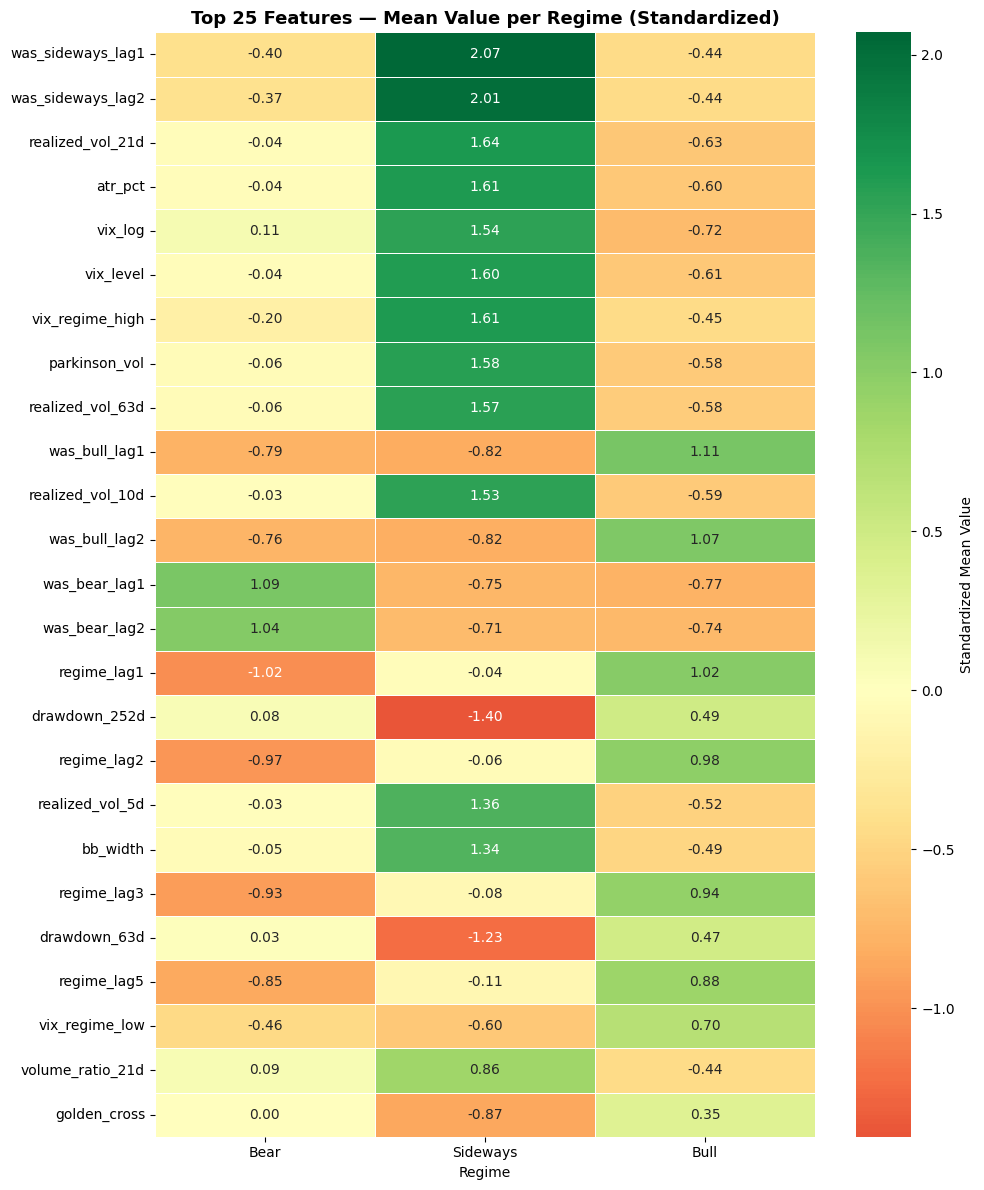


Top 5 most discriminating features:
was_sideways_lag1    2.067069
was_sideways_lag2    1.954167
realized_vol_21d     1.385142
atr_pct              1.324081
vix_log              1.316780
Name: variance, dtype: float64


In [13]:
# Compute per-regime mean of each feature (normalized)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(feature_matrix[feature_cols]),
    index=feature_matrix.index,
    columns=feature_cols
)

regime_means = {}
for regime_code, regime_name in {0: 'Bear', 1: 'Sideways', 2: 'Bull'}.items():
    mask = feature_matrix['target_regime_code'] == regime_code
    regime_means[regime_name] = X_scaled[mask].mean()

regime_profile = pd.DataFrame(regime_means)

# Show top 20 most discriminating features (highest variance across regimes)
regime_profile['variance'] = regime_profile.var(axis=1)
top_features = regime_profile.nlargest(25, 'variance').drop(columns='variance')

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    top_features,
    cmap='RdYlGn', center=0, annot=True, fmt='.2f',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Standardized Mean Value'}
)
ax.set_title('Top 25 Features — Mean Value per Regime (Standardized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Regime')
plt.tight_layout()
plt.savefig('plots/05_feature_regime_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most discriminating features:')
print(regime_profile['variance'].nlargest(5))

In [14]:
# 4.2 Correlation matrix of features (check for multicollinearity)
corr = feature_matrix[feature_cols].corr()

# Find highly correlated pairs (|r| > 0.90)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.90:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

print(f'Highly correlated feature pairs (|r| > 0.90): {len(high_corr_pairs)}')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:15]:
    print(f'  {a:35s} ↔  {b:35s}  r={r}')

Highly correlated feature pairs (|r| > 0.90): 44
  ret_5d                              ↔  ret_mean_5d                          r=1.0
  ret_10d                             ↔  ret_mean_10d                         r=1.0
  ret_21d                             ↔  ret_mean_21d                         r=1.0
  ret_63d                             ↔  ret_mean_63d                         r=1.0
  ret_5d                              ↔  roc_5d                               r=0.999
  ret_mean_5d                         ↔  roc_5d                               r=0.999
  bb_pct_b                            ↔  zscore_21d                           r=0.999
  ret_21d                             ↔  roc_21d                              r=0.996
  ret_mean_21d                        ↔  roc_21d                              r=0.996
  was_bull_lag1                       ↔  was_bull_lag2                        r=0.969
  vix_level                           ↔  vix_log                              r=0.964
  regime_lag1

In [15]:
# 4.3 Quick Feature Importance using a shallow Random Forest
# This is NOT your final model — just a fast signal quality check
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = feature_matrix[feature_cols].values
y = feature_matrix['target_regime_code'].values.astype(int)

# Simple train/test split for exploration only (NOT proper walk-forward — that's Notebook 03)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False preserves time order
)

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)

print(f'Quick RF accuracy (train/test split, NOT walk-forward): {rf.score(X_test, y_test):.3f}')
print('⚠️  This is an optimistic estimate — use walk-forward in Notebook 03 for real evaluation')

Quick RF accuracy (train/test split, NOT walk-forward): 0.958
⚠️  This is an optimistic estimate — use walk-forward in Notebook 03 for real evaluation


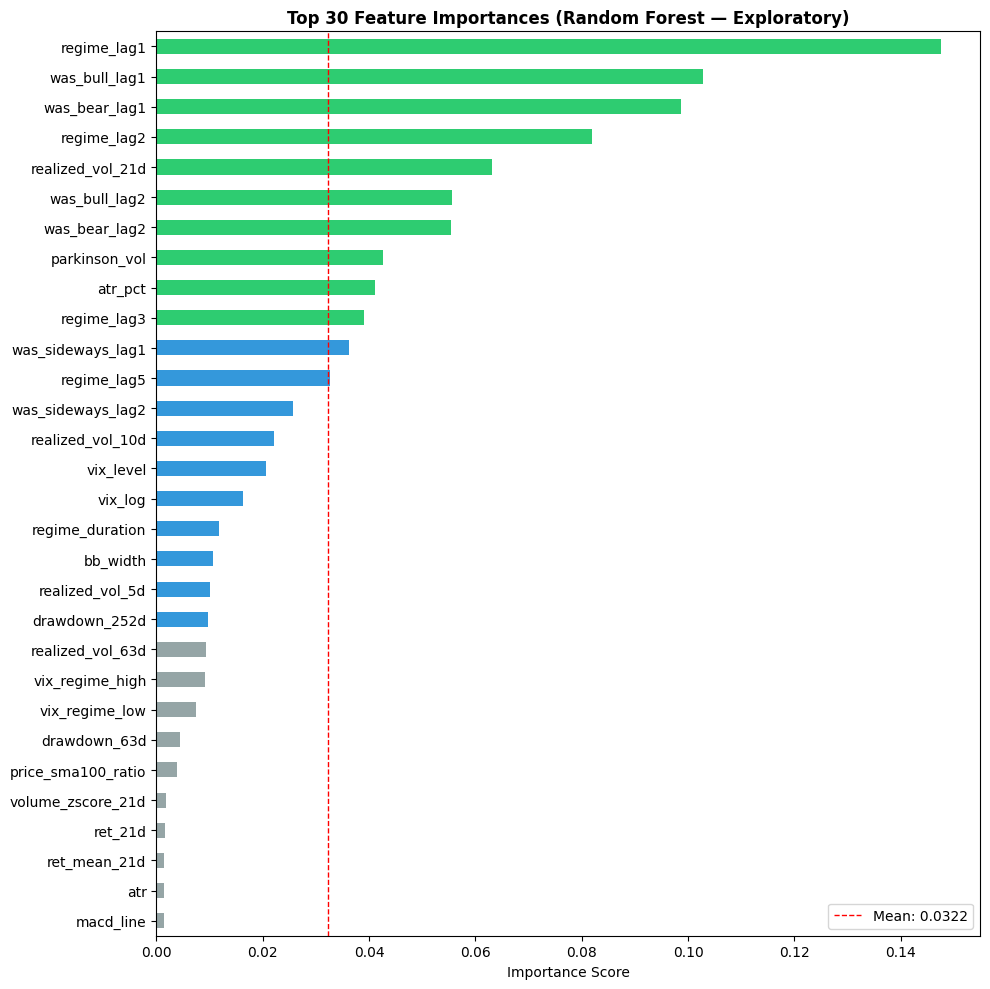

Top 10 features by importance:
regime_lag1         0.1475
was_bull_lag1       0.1029
was_bear_lag1       0.0987
regime_lag2         0.0819
realized_vol_21d    0.0632
was_bull_lag2       0.0557
was_bear_lag2       0.0553
parkinson_vol       0.0426
atr_pct             0.0410
regime_lag3         0.0390


In [16]:
# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top30 = importances.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if i < 10 else '#3498db' if i < 20 else '#95a5a6'
          for i in range(len(top30))]
top30.sort_values().plot.barh(ax=ax, color=colors[::-1])
ax.set_title('Top 30 Feature Importances (Random Forest — Exploratory)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(top30.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {top30.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('plots/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by importance:')
print(top30.head(10).round(4).to_string())

In [17]:
def remove_correlated_features(
    feature_cols: list,
    corr_matrix: pd.DataFrame,
    importances: pd.Series,
    threshold: float = 0.92
) -> list:
    """
    Greedy removal of correlated features.
    When two features are highly correlated, drop the one with lower importance.
    """
    to_drop = set()
    cols = list(feature_cols)

    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i+1, len(cols)):
            if cols[j] in to_drop:
                continue
            r = abs(corr_matrix.loc[cols[i], cols[j]])
            if r > threshold:
                # Drop the one with lower importance
                imp_i = importances.get(cols[i], 0)
                imp_j = importances.get(cols[j], 0)
                drop_col = cols[j] if imp_i >= imp_j else cols[i]
                to_drop.add(drop_col)

    kept = [c for c in cols if c not in to_drop]
    print(f'Removed {len(to_drop)} correlated features | Kept {len(kept)}')
    return kept


selected_features = remove_correlated_features(
    feature_cols,
    corr,
    importances,
    threshold=0.92
)

print(f'\nFinal selected features: {len(selected_features)}')

Removed 23 correlated features | Kept 52

Final selected features: 52


In [18]:
print('\nSelected features:', selected_features)


Selected features: ['ret_1d', 'ret_2d', 'ret_3d', 'ret_21d', 'ret_mean_5d', 'up_frac_5d', 'up_frac_21d', 'price_sma20_ratio', 'price_sma50_ratio', 'price_sma100_ratio', 'price_sma200_ratio', 'sma50_200_ratio', 'golden_cross', 'macd_line', 'macd_hist', 'macd_crossover', 'adx', 'adx_pos', 'adx_neg', 'adx_trend_strength', 'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d', 'vol_ratio_5_21', 'atr', 'bb_width', 'bb_squeeze', 'rsi_7', 'rsi_28', 'drawdown_252d', 'drawdown_63d', 'ret_zscore_21d', 'stoch_d', 'volume_zscore_21d', 'obv_trend', 'up_down_vol_ratio', 'pv_divergence', 'vix_level', 'vix_chg_1d', 'vix_chg_5d', 'vix_chg_21d', 'vix_zscore_252d', 'vix_regime_low', 'vix_regime_high', 'vix_above_ma21', 'regime_lag1', 'regime_lag5', 'regime_duration', 'was_sideways_lag1', 'was_bull_lag2', 'was_bear_lag2']


In [19]:
# Save full feature matrix (all features)
feature_matrix.to_csv('data/02_feature_matrix.csv')

# Save selected feature list
with open('data/selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

# Save feature importance scores
importances.to_csv('data/feature_importances.csv')

print('✅ Saved: data/02_feature_matrix.csv')
print('✅ Saved: data/selected_features.pkl')
print('✅ Saved: data/feature_importances.csv')
print()
print('=== FEATURE SUMMARY ===')
categories = {
    'Momentum'        : [c for c in selected_features if 'ret_' in c or 'roc_' in c or 'up_frac' in c],
    'Trend'           : [c for c in selected_features if 'sma' in c or 'macd' in c or 'adx' in c or 'golden' in c],
    'Volatility'      : [c for c in selected_features if 'vol' in c or 'atr' in c or 'bb_' in c or 'parkinson' in c],
    'Mean Reversion'  : [c for c in selected_features if 'rsi' in c or 'zscore' in c or 'drawdown' in c or 'stoch' in c],
    'Volume'          : [c for c in selected_features if 'volume' in c or 'obv' in c or 'pv_' in c or 'up_down' in c],
    'Macro'           : [c for c in selected_features if 'vix' in c or 'yield' in c],
    'Regime Lags'     : [c for c in selected_features if 'regime' in c or 'was_' in c],
}
for cat, feats in categories.items():
    print(f'  {cat:<18}: {len(feats):2d} features')

✅ Saved: data/02_feature_matrix.csv
✅ Saved: data/selected_features.pkl
✅ Saved: data/feature_importances.csv

=== FEATURE SUMMARY ===
  Momentum          :  8 features
  Trend             : 13 features
  Volatility        : 10 features
  Mean Reversion    :  8 features
  Volume            :  4 features
  Macro             :  8 features
  Regime Lags       :  8 features
